# Hourly Electricity Demand Forecasting

This notebook uses the PJME hourly electricity demand dataset to build a machine learning workflow for short-term load forecasting.

## Workflow
1. Load and preprocess the dataset  
2. Validate timestamps and data consistency  
3. Create calendar, cyclical, lag, and rolling features  
4. Train multiple regression models  
5. Evaluate them with a chronological train/test split  
6. Validate robustness with time-series cross-validation  

## Pipeline overview

Raw data → Preprocessing → Feature Engineering → Train/Test Split → Model Training → Evaluation

## Models compared
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The goal is not only to obtain strong predictive performance, but also to keep the pipeline clear, modular, and reproducible.

## Configuration

In [ ]:
# =========================
# Project configuration
# =========================

DATA_PATH = "../data/PJME_hourly.csv"
TARGET_COL = "PJME_MW"

TEST_SIZE = 0.2
RANDOM_STATE = 42

# plotting window (first month)
PLOT_HOURS = 24 * 30

## Imports

In [3]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

from src.preprocessing import load_data, sort_by_time
from src.features import create_features
from src.train import (
    make_Xy,
    make_train_test_split,
    build_ridge_pipeline,
    build_random_forest_model,
    build_gradient_boosting_model,
    fit_predict,
)
from src.evaluate import evaluate_regression

## Data loading and preprocessing

I load the PJM East hourly load dataset, standardize the timestamp column name, convert it to datetime format, and sort the series chronologically.

In [5]:
df = load_data("../data/PJME_hourly.csv")
df = sort_by_time(df)

print("Raw shape:", df.shape)
df.head()

Raw shape: (145366, 1)


,PJME_MW
timestamp,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Data quality checks

Before feature engineering, I run a few basic checks to confirm that the time series is usable:
- timestamps are sorted
- duplicated timestamps are identified
- missing target values are counted
- the dominant time step is inspected

These checks are especially important in forecasting projects because lag and rolling features assume a consistent chronological structure.

In [6]:
def run_data_checks(df, target_col=TARGET_COL):
    checks = {
        "sorted_index": df.index.is_monotonic_increasing,
        "duplicate_timestamps": int(df.index.duplicated().sum()),
        "missing_target_values": int(df[target_col].isna().sum()),
        "negative_target_values": int((df[target_col] < 0).sum()),
    }

    time_deltas = df.index.to_series().diff().value_counts().head()
    return checks, time_deltas


checks, time_deltas = run_data_checks(df)

print("Data checks")
for name, value in checks.items():
    print(f"- {name}: {value}")

print("\nMost common time deltas:")
print(time_deltas)

Data checks
- sorted_index: True
- duplicate_timestamps: 4
- missing_target_values: 0
- negative_target_values: 0

Most common time deltas:
timestamp
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [7]:
# Remove duplicated timestamps, if any, keeping the first occurrence
df = df[~df.index.duplicated(keep="first")].copy()

print("Shape after duplicate handling:", df.shape)

Shape after duplicate handling: (145362, 1)


## Feature engineering

I create four groups of predictors:
- **calendar features**: hour, day of week, month, weekend flag
- **cyclical features**: sine/cosine encodings for hour and weekday
- **lag features**: previous hour, previous day, previous week
- **rolling statistics**: past 24-hour mean and standard deviation

Rolling features are computed using only past values to avoid target leakage.

In [8]:
features_df = create_features(df)

print("Feature matrix shape:", features_df.shape)
features_df.head()

Feature matrix shape: (145194, 14)


,PJME_MW,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
timestamp,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,1,0,0.258819,0.965926,0.781831,0.62349,31187.0,26862.0,30393.0,33452.583333,4559.767709
2002-01-08 02:00:00,28670.0,2,1,1,0,0.500000,0.866025,0.781831,0.62349,29445.0,25976.0,29265.0,33560.208333,4425.965952
2002-01-08 03:00:00,28375.0,3,1,1,0,0.707107,0.707107,0.781831,0.62349,28670.0,25641.0,28357.0,33672.458333,4256.159403
2002-01-08 04:00:00,28542.0,4,1,1,0,0.866025,0.500000,0.781831,0.62349,28375.0,25666.0,27899.0,33786.375000,4064.104959
2002-01-08 05:00:00,29261.0,5,1,1,0,0.965926,0.258819,0.781831,0.62349,28542.0,26328.0,28057.0,33906.208333,3851.076461


## Train/test split

Since this is a forecasting task, I use a **chronological split** rather than a random split.  
This keeps the temporal order intact and better reflects a realistic prediction setting.

In [9]:
X, y = make_Xy(features_df, target_col=TARGET_COL)
X_train, X_test, y_train, y_test = make_train_test_split(X, y, test_size=TEST_SIZE)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (116155, 13)
X_test : (29039, 13)
y_train: (116155,)
y_test : (29039,)


## Model training and evaluation

I compare a linear baseline against two tree-based ensemble models:

- **Ridge Regression** as a regularized linear benchmark, implemented within a scikit-learn Pipeline  
- **Random Forest Regressor**
- **Gradient Boosting Regressor**

This setup makes it possible to compare a simple linear approach with more flexible non-linear models.  
Using a shared dictionary of models also keeps the workflow compact, consistent, and easy to extend with additional estimators.

In [10]:
models = {
    "Ridge": build_ridge_pipeline(alpha=1.0),
    "Random Forest": build_random_forest_model(
        n_estimators=200,
        max_depth=None,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": build_gradient_boosting_model(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

test_predictions = {}
test_results = {}

for name, model in models.items():
    preds = fit_predict(model, X_train, y_train, X_test)
    test_predictions[name] = preds
    test_results[name] = evaluate_regression(y_test, preds)

results_df = (
    pd.DataFrame(test_results)
    .T
    .sort_values("rmse")
    .round(2)
)

results_df

,rmse,mae,r2
Random Forest,422.80,306.85,1.00
Gradient Boosting,626.09,484.07,0.99
Ridge,991.77,776.96,0.98


## Test-set performance

The table above compares the models on the holdout test set using:

- **RMSE**: penalizes large errors more strongly  
- **MAE**: average absolute error  
- **R²**: proportion of explained variance  

The **Ridge regression baseline** already performs well, explaining roughly **98% of the variance** in electricity demand.  
This indicates that the engineered temporal features — including lag variables, cyclical encodings, and calendar indicators — capture a large share of the underlying structure in the time series.

However, both tree-based ensemble models further reduce the prediction errors.  
This suggests that the relationship between predictors and electricity demand is not purely linear and benefits from models that can capture **non-linear interactions between features**.

Among the evaluated models, **Random Forest** delivers the strongest overall performance, achieving the lowest RMSE and MAE while maintaining an R² close to 1.  
**Gradient Boosting** also improves substantially over the linear baseline, although it does not outperform Random Forest in this configuration.

**Takeaway:** tree-based ensemble models outperform the linear baseline, with **Random Forest** providing the most accurate predictions on the test set.

In [11]:
best_model_name = results_df.index[0]
best_model_name

'Random Forest'

## Prediction plots

To make the comparison more interpretable, I visualize:

1. actual vs predicted demand for the best model  
2. residuals over time for the best model  
3. actual vs predicted demand for all models on the same window  

These plots complement the numerical metrics by showing how the models behave over time.  
They help assess not only overall accuracy, but also whether predictions follow the main demand dynamics and where the largest deviations occur.

For readability, the plots focus on the first month of the test period.

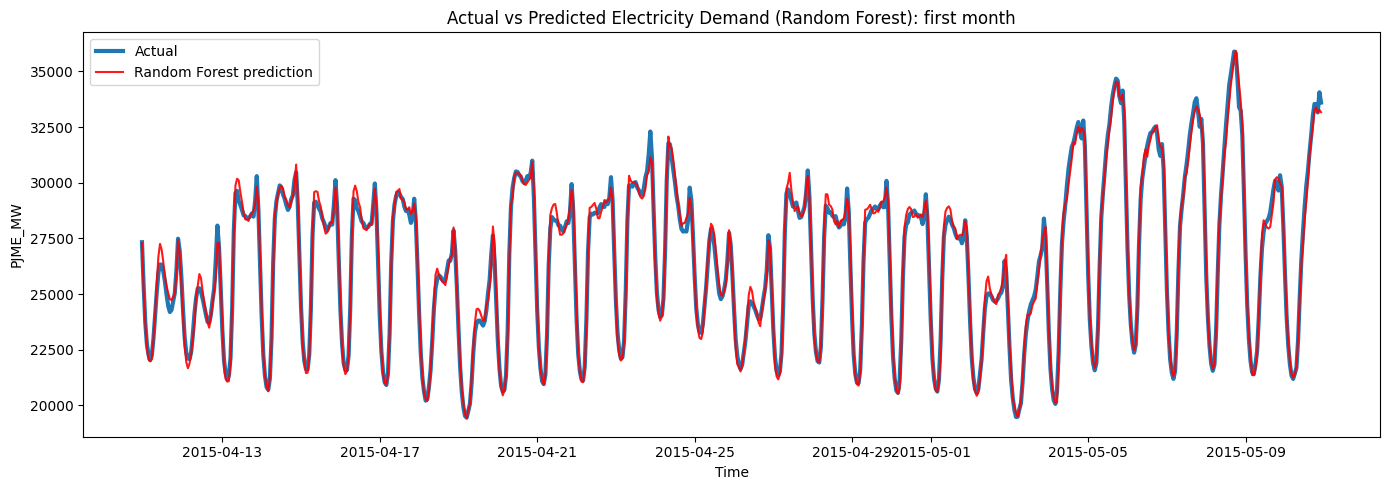

In [12]:
best_preds = test_predictions["Random Forest"]

plt.figure(figsize=(14, 5))
plt.plot(y_test.iloc[:PLOT_HOURS].index, y_test.iloc[:PLOT_HOURS], label="Actual", linewidth=3)
plt.plot(
    y_test.iloc[:PLOT_HOURS].index,
    best_preds[:PLOT_HOURS],
    color="red",
    label="Random Forest prediction",
    alpha=0.9,
)
plt.title("Actual vs Predicted Electricity Demand (Random Forest): first month")
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.legend()
plt.tight_layout()
plt.show()

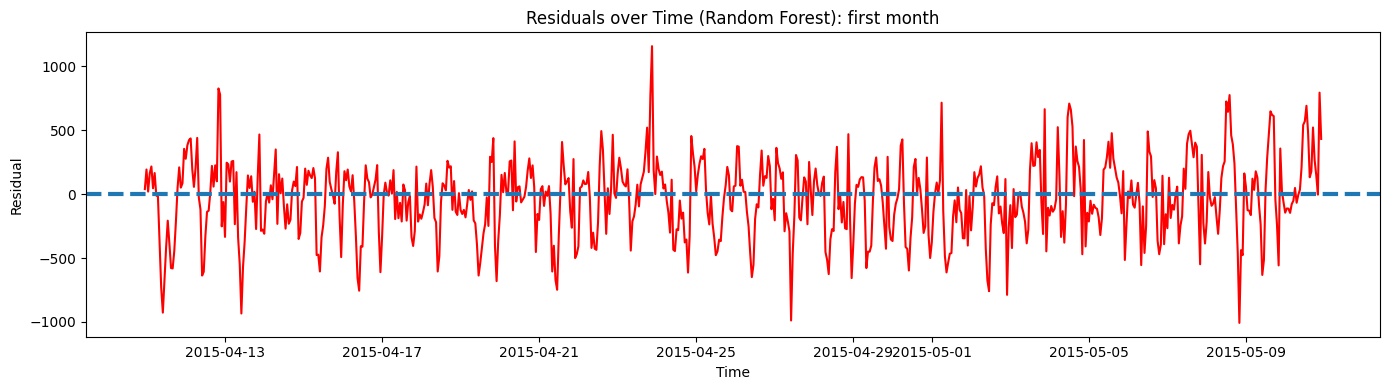

In [13]:
residuals = y_test - best_preds

plt.figure(figsize=(14, 4))
plt.plot(y_test.iloc[:PLOT_HOURS].index, residuals.iloc[:PLOT_HOURS], color="red")
plt.axhline(0, linestyle="--", linewidth=3)
plt.title("Residuals over Time (Random Forest): first month")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

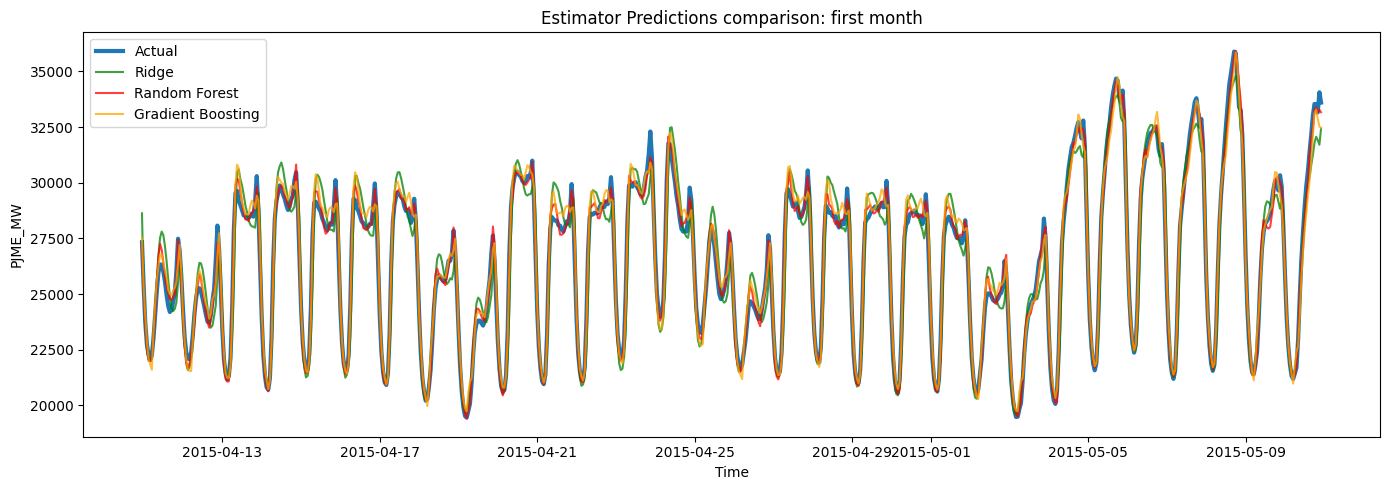

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.iloc[:PLOT_HOURS].index, y_test.iloc[:PLOT_HOURS], label="Actual", linewidth=3)

model_colors = {
    "Ridge": "green",
    "Random Forest": "red",
    "Gradient Boosting": "orange"
}

for name, preds in test_predictions.items():
    plt.plot(
        y_test.iloc[:PLOT_HOURS].index,
        preds[:PLOT_HOURS],
        label=name,
        color=model_colors[name],
        alpha=0.75
    )

plt.title("Estimator Predictions comparison: first month")
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.legend()
plt.tight_layout()
plt.show()

## Feature importance

For interpretability, I inspect feature importance from the Random Forest model.

This helps answer a practical question: **which signals are driving the forecast most strongly?**  
In load forecasting, lag features are often dominant because electricity demand usually shows strong short-term persistence.

In [16]:
random_forest_model = models["Random Forest"]

feature_importances = (
    pd.Series(random_forest_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

feature_importances.head(10)

lag_1              0.948874
hour_cos           0.025393
hour               0.010383
hour_sin           0.005370
rolling_std_24     0.003710
rolling_mean_24    0.001542
month              0.001187
lag_24             0.001039
dayofweek          0.000668
dow_sin            0.000638
dtype: float64

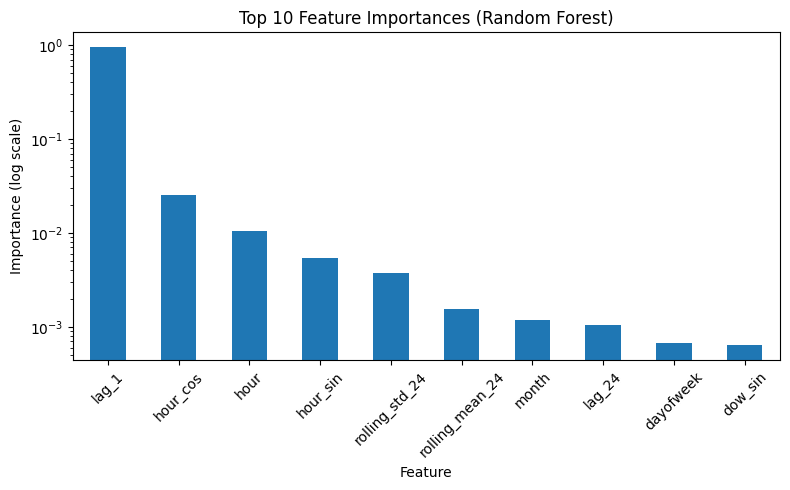

In [17]:
plt.figure(figsize=(8, 5))
feature_importances.head(10).plot(kind="bar")
plt.yscale("log")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The feature importance ranking is clearly dominated by `lag_1`, indicating strong short-term autocorrelation in hourly electricity demand: the most recent observation is by far the most informative predictor for the next hour.

Daily (`lag_24`) and weekly (`lag_168`) lag features still provide useful information, although their contribution is smaller. Much of the temporal structure they capture is already reflected in the immediate past value of the series.

Calendar features and cyclical encodings (`hour`, `hour_sin`, `hour_cos`) help the model capture **regular daily patterns**, while rolling statistics provide additional information about short-term variability.

Overall, the results confirm that electricity demand is highly autocorrelated and that **recent historical values carry the strongest predictive signal**.  
In practical forecasting systems, additional external variables—such as weather conditions, temperature, or holiday indicators—are often included to further improve predictive performance.

## Time-series cross-validation

A single train/test split is useful, but I also want to verify that the ranking of the models is stable across multiple chronological folds.

I therefore use **TimeSeriesSplit**, which respects time order and avoids leakage from future observations into past training windows.

Unlike standard cross-validation, this approach evaluates the models on progressively later segments of the time series, providing a more realistic estimate of how the models would perform in a real forecasting scenario.

In [18]:
tsscv = TimeSeriesSplit(n_splits=5)

cv_results = {name: [] for name in models}

for train_idx, val_idx in tsscv.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    for name, model in models.items():
        model_cv = clone(model)
        preds_cv = fit_predict(model_cv, X_train_cv, y_train_cv, X_val_cv)
        rmse_cv = evaluate_regression(y_val_cv, preds_cv)["rmse"]
        cv_results[name].append(rmse_cv)

cv_rmse_df = pd.DataFrame(cv_results, index=[f"Fold {i}" for i in range(1, 6)])
cv_rmse_df.round(2)

,Ridge,Random Forest,Gradient Boosting
Fold 1,1051.53,515.21,684.57
Fold 2,1023.33,395.93,625.30
Fold 3,1029.81,412.70,657.93
Fold 4,1011.64,420.80,653.72
Fold 5,1006.21,422.22,644.04


In [19]:
cv_summary_df = pd.DataFrame({
    "mean_rmse": cv_rmse_df.mean(),
    "std_rmse": cv_rmse_df.std()
}).sort_values("mean_rmse").round(2)

cv_summary_df

,mean_rmse,std_rmse
Random Forest,433.37,46.93
Gradient Boosting,653.11,21.62
Ridge,1024.50,17.75


The table above summarizes the **mean and standard deviation of RMSE across folds**.

The cross-validation results confirm the same overall pattern observed on the holdout test set.  
**Random Forest** achieves the lowest average error (mean RMSE ≈ 433 MW) and consistently delivers the strongest predictive performance across folds.

**Gradient Boosting** remains competitive but does not surpass Random Forest in this configuration, while the linear baseline (**Ridge**) performs noticeably worse. This suggests that the electricity demand series contains important **non-linear relationships** that are better captured by ensemble tree models than by a linear approach.

Overall, the cross-validation results indicate that **Random Forest provides the best combination of accuracy and stability across different temporal splits of the data**, reinforcing the conclusions drawn from the single train/test evaluation.

## Final conclusions

This project demonstrates a complete machine learning workflow for hourly electricity demand forecasting, from data preprocessing and feature engineering to model comparison and time-aware validation.

Feature engineering plays a central role in this task. Lag variables and temporal features capture the strong autocorrelation and recurring daily patterns that characterize electricity demand.

### Main findings

- Lag-based features carry most of the predictive signal, confirming the strong short-term persistence of electricity demand.
- A chronological evaluation setup (train/test split and TimeSeriesSplit) is essential to obtain realistic performance estimates for time-series forecasting tasks.
- Tree-based ensemble models outperform the linear baseline, indicating that the relationship between predictors and demand is not purely linear.
- In this configuration, **Random Forest provides the best predictive performance**, achieving the lowest errors on both the holdout test set and the cross-validation folds.

Overall, the results show that relatively simple machine learning models can produce accurate electricity demand forecasts when temporal structure is carefully encoded.  
Future improvements could include incorporating **exogenous variables** such as temperature, weather conditions, or holiday indicators, which are known to influence electricity consumption.